# nb28 — Should we build head v2 and adopt router v2? The truth-based test

Both proposals rest on evidence with soft spots: the head-v2 case (nb26) used equal-SNR
injections and per-source ridge readers; the router-v2 faint-end case (nb27) used a
truth-free half-split proxy. This notebook runs the one experiment that tests both against
**known truth under realistic conditions**: sources injected with per-band SNR ratios
drawn from the real-source census (nb26), across VIS peak SNR 5–25, into held-out tiles;
every estimator and both pooling strategies run on identical noise realizations.

- **Decision plot 1 (head v2):** median radial error vs VIS SNR for the classical VIS
  centroid, the current head, the joint 10-band fit (what a multi-band reader could
  reach), and the SED-matched CRB. The gap between the head and the joint fit, at real
  SEDs and faint SNR, is the head-v2 case — if it closes on its own, there is no case.
- **Decision plot 2 (router v2):** per-band positions pooled by unweighted median (v1
  aggregation) vs calibrated inverse variance (v2), against truth, with weights fit on a
  disjoint calibration split. If IV does not beat median here, do not adopt it.

Injections treat each band's WCS as truth, so this measures the **statistical** budget;
on real sky the bright end is additionally floored by the shared systematics of nb25 §5 /
nb27 (concordance field). The faint end is statistics-dominated, so these curves are
representative exactly where both v2 proposals claim their value.

In [1]:
import sys, json, time
from pathlib import Path

def find_repo_root(s=None):
    s = (s or Path.cwd()).resolve()
    for c in [s, *s.parents]:
        if (c/'models').exists() and (c/'data').exists():
            return c
    raise FileNotFoundError('repo root')

REPO = find_repo_root()
for p in (REPO/'models', REPO, REPO/'models'/'astrometry2'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import torch
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from scipy.spatial import cKDTree
from scipy.optimize import least_squares

from astrometry2.latent_position_head import load_latent_position_head
from astrometry2.source_matching import safe_header_from_card_string
from astrometry2.dataset import (build_full_context_detector_inputs,
                                 local_vis_pixel_to_sky_matrix)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
OUT = REPO/'io'/'_nb28_outputs'
OUT.mkdir(exist_ok=True)

FOUNDATION = REPO/'models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt'
HEAD_CKPT  = REPO/'models/checkpoints/latent_position_q1_vissep_patchval25/best.pt'
CFG = dict(n_tiles=6, n_src=20, seed=20260811,
           snr_levels=[5.0, 7.0, 10.0, 15.0, 25.0],
           n_real=12, n_cal=5)        # first n_cal realizations calibrate weights; rest test
# 6 tiles x 20 src x 7 test realizations = 840 error samples per (method, level):
# ~4% precision on each median, with cluster-bootstrap CIs computed below
SIGMA_PX = {'VIS': 2.5/2.355, 'NISP': 2.5/2.355, 'RUBIN': 3.0/2.355}
RUBIN_BANDS = ['u','g','r','i','z','y']
NISP_BANDS  = ['Y','J','H']
VIS_MAS = 100.0

ck = torch.load(HEAD_CKPT, map_location='cpu', weights_only=False)
hcfg = ck.get('config', {})
fe, head = load_latent_position_head(str(FOUNDATION), device=DEVICE,
                                     bottleneck_window=hcfg.get('bottleneck_window', 5) or 5,
                                     stem_window=hcfg.get('stem_window', 17) or 17)
head.load_state_dict(ck['head_state_dict'])
head.eval()

LAB = torch.load(REPO/'data/detection_labels/centernet_q1_790_vissep_thresh03.pt',
                 map_location='cpu', weights_only=False)
LAB = LAB['labels'] if 'labels' in LAB else LAB
rdir, edir = REPO/'data/rubin_tiles_patch25', REPO/'data/euclid_tiles_all_q1'
STEMS25 = sorted(p.name[:-4] for p in rdir.glob('tile_*.npz'))

# realistic SEDs: per-band peak-SNR ratios of real sources (nb26 census)
sed = np.load(REPO/'io/_nb26_outputs/step0_sed_census.npz', allow_pickle=True)
SNRm, SED_BANDS = np.asarray(sed['snr']), list(sed['bands'])
vis_i = SED_BANDS.index('euclid_VIS')
ok = np.isfinite(SNRm[:, vis_i]) & (SNRm[:, vis_i] > 8) & (SNRm[:, vis_i] < 100)
ratios_all = np.nan_to_num(SNRm[ok]/SNRm[ok, vis_i][:, None], nan=0.0)
ratios_all = np.clip(ratios_all, 0.0, 3.0)
rng0 = np.random.default_rng(CFG['seed'])
SEDS = ratios_all[rng0.choice(len(ratios_all), CFG['n_tiles']*CFG['n_src'], replace=False)]
print(f'{len(ratios_all)} census SEDs available; drew {len(SEDS)}; '
      f'median non-VIS ratio {np.median(SEDS[:, [i for i in range(10) if i != vis_i]]):.2f}')

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt
  bottleneck_window=5  (physical coverage: 2.0" at 0.40"/px)
LatentPositionHead: 0.69M trainable, 7.3M frozen encoder  (v10 foundation)


741 census SEDs available; drew 120; median non-VIS ratio 0.42


## The engine

Per tile: injection sites away from real sources; per source a fixed real SED. Per
(VIS-SNR level, realization): fresh noise in all ten bands, per-band amplitudes
$\rm{snr_{VIS}\times ratio_b\times rms_b}$, then on identical images —

- per-band single-band $\chi^2$ fits (shared VIS-px parametrization through each band's
  local WCS affine; per-band amplitude + background profiled out) with a validity gate at
  measured peak S/N > 3, mirroring the eval pipeline's signal mask;
- the current position head, queried at the VIS classical position (production
  convention at the faint end);
- the joint 10-band fit (one shared position, all stamps);
- the analytic SED-matched CRB (all bands, exact).

Median-pool and IV-pool aggregate the same per-band fits; IV weights are the empirical
per-(band, level) error scales from the calibration realizations only.

In [2]:
def local_rms(rms_img, x, y):
    xi = int(np.clip(round(float(x)), 0, rms_img.shape[1]-1))
    yi = int(np.clip(round(float(y)), 0, rms_img.shape[0]-1))
    v = float(rms_img[yi, xi])
    return v if np.isfinite(v) and v > 0 else float(np.nanmedian(rms_img))

def pixel_fisher_band(amp, x, y, sigma, var_local):
    r = int(max(8, np.ceil(5*sigma)))
    yy, xx = np.mgrid[-r:r+1, -r:r+1].astype(np.float64)
    xx += (x - round(x)); yy += (y - round(y))
    g = np.exp(-0.5*(xx**2 + yy**2)/sigma**2)
    return float(((amp*(xx/sigma**2)*g)**2).sum()/var_local)

def inject_gauss(img, x, y, sigma, amp):
    Hh, Ww = img.shape
    r = int(max(6, np.ceil(4*sigma)))
    x0, x1 = max(0, int(x)-r), min(Ww, int(x)+r+1)
    y0, y1 = max(0, int(y)-r), min(Hh, int(y)+r+1)
    yy, xx = np.mgrid[y0:y1, x0:x1]
    img[y0:y1, x0:x1] += (amp*np.exp(-0.5*(((xx-x)/sigma)**2 + ((yy-y)/sigma)**2))).astype(img.dtype)

class TileCtx:
    def __init__(self, stem, sed_rows):
        rdata = dict(np.load(rdir/f'{stem}.npz', allow_pickle=True))
        edata = dict(np.load(edir/f'{stem}_euclid.npz', allow_pickle=True))
        self.vwcs = WCS(safe_header_from_card_string(edata['wcs_VIS'].item()))
        rwcs = WCS(rdata['wcs_hdr'].item())
        self.base, self.rms, self.vis_hw = build_full_context_detector_inputs(
            edata, rdata['img'], rubin_var=rdata.get('var'))
        H, W = self.vis_hw
        self.binfo = {}
        for b in ['VIS'] + NISP_BANDS:
            w = self.vwcs if b == 'VIS' else WCS(safe_header_from_card_string(edata[f'wcs_{b}'].item()))
            self.binfo[f'euclid_{b}'] = (w, SIGMA_PX['VIS' if b == 'VIS' else 'NISP'])
        for b in RUBIN_BANDS:
            self.binfo[f'rubin_{b}'] = (rwcs, SIGMA_PX['RUBIN'])
        rng = np.random.default_rng(CFG['seed'] + hash(stem) % 1000)
        ent = LAB[stem]
        xyn = np.asarray(ent[0] if isinstance(ent, tuple) else ent, dtype=np.float32)
        tree = cKDTree(np.stack([xyn[:, 0]*(W-1), xyn[:, 1]*(H-1)], axis=1))
        pts = []
        while len(pts) < CFG['n_src']:
            x, y = rng.uniform(120, W-120), rng.uniform(120, H-120)
            if np.isfinite(tree.query([[x, y]], distance_upper_bound=25.0)[0][0]):
                continue
            if pts and np.min(np.hypot(*(np.asarray(pts) - [x, y]).T)) < 80:
                continue
            pts.append([x, y])
        self.pts = np.asarray(pts, np.float32)
        self.ra0, self.dec0 = self.vwcs.pixel_to_world_values(self.pts[:, 0], self.pts[:, 1])
        self.pix2sky = np.stack([local_vis_pixel_to_sky_matrix(self.vwcs, p) for p in self.pts]).astype(np.float32)
        self.seds = sed_rows                     # [n_src, 10] in SED_BANDS order
        self.rms_t = {b: torch.from_numpy(r_[None, None].copy()).float().to(DEVICE)
                      for b, r_ in self.rms.items()}
        # per band: truth px, local affine, stamp contexts, per-source amplitude
        self.bpx, self.A, self.ctx, self.amps = {}, {}, {}, {}
        for band, (bw, sig) in self.binfo.items():
            bx, by = bw.world_to_pixel_values(self.ra0, self.dec0)
            self.bpx[band] = np.stack([bx, by], axis=1).astype(np.float64)
            A = np.zeros((len(pts), 2, 2))
            for a in range(2):
                e = np.eye(2)[a]
                ra_e, dec_e = self.vwcs.pixel_to_world_values(self.pts[:, 0]+e[0], self.pts[:, 1]+e[1])
                bx_e, by_e = bw.world_to_pixel_values(ra_e, dec_e)
                A[:, 0, a] = bx_e - bx
                A[:, 1, a] = by_e - by
            self.A[band] = A
            R = 9 if band.startswith('euclid') else 6
            for k in range(len(pts)):
                cx, cy = self.bpx[band][k]
                x0, y0 = int(round(cx))-R, int(round(cy))-R
                st_rms = self.rms[band][y0:y0+2*R+1, x0:x0+2*R+1]
                yy, xx = np.mgrid[y0:y0+2*R+1, x0:x0+2*R+1]
                self.ctx[band, k] = (xx.astype(np.float64), yy.astype(np.float64),
                                     (1.0/np.clip(st_rms, 1e-12, None)**2).astype(np.float64),
                                     (x0, y0, R))
            ib = SED_BANDS.index(band)
            self.amps[band] = np.array([local_rms(self.rms[band], bx[k], by[k])*self.seds[k, ib]
                                        for k in range(len(pts))])   # amp per unit VIS peak SNR

    def fit(self, imgs, bands, k, dxy0=(0.0, 0.0)):
        # shared-position chi2 fit over `bands`; returns (dxy in VIS px, per-band fitted amp)
        stamps = []
        for b in bands:
            x0, y0, R = self.ctx[b, k][3]
            stamps.append(imgs[b][y0:y0+2*R+1, x0:x0+2*R+1].astype(np.float64))
        amps_out = {}
        def resid(dxy):
            res = []
            for b, st in zip(bands, stamps):
                xx, yy, w, _ = self.ctx[b, k]
                sig = self.binfo[b][1]
                c = self.bpx[b][k] + self.A[b][k] @ dxy
                g = np.exp(-0.5*(((xx-c[0])/sig)**2 + ((yy-c[1])/sig)**2))
                M = np.stack([g.ravel(), np.ones(g.size)], axis=1)
                Wv = w.ravel()
                coef = np.linalg.solve(M.T @ (M*Wv[:, None]), M.T @ (Wv*st.ravel()))
                amps_out[b] = coef[0]
                res.append((st.ravel() - M @ coef)*np.sqrt(Wv))
            return np.concatenate(res)
        try:
            sol = least_squares(resid, list(dxy0), bounds=(-3, 3), diff_step=0.05)
            resid(sol.x)
            return sol.x, dict(amps_out)
        except Exception:
            return np.array([np.nan, np.nan]), {b: np.nan for b in bands}

TILES = [TileCtx(STEMS25[i], SEDS[i*CFG['n_src']:(i+1)*CFG['n_src']]) for i in range(CFG['n_tiles'])]
ALL_BANDS = list(TILES[0].binfo)
print('tiles ready:', [STEMS25[i] for i in range(CFG['n_tiles'])])

tiles ready: ['tile_x00000_y00000_tract5063_patch_25', 'tile_x00000_y00256_tract5063_patch_25', 'tile_x00000_y00512_tract5063_patch_25', 'tile_x00000_y00768_tract5063_patch_25', 'tile_x00000_y01024_tract5063_patch_25', 'tile_x00000_y01280_tract5063_patch_25']


In [3]:
CACHE = OUT/'v2_decision_records.json'
expected = CFG['n_tiles']*len(CFG['snr_levels'])*CFG['n_real']*CFG['n_src']
if CACHE.exists() and len(json.load(open(CACHE))) == expected:
    records = json.load(open(CACHE))
    print(f'loaded {len(records)} cached records')
else:
    # main loop: levels x realizations x tiles -> per-band fits + head + joint, all vs truth
    records = []      # dict per (tile, level, realization, src)
    t0 = time.time()
    for ti, T in enumerate(TILES):
        n = len(T.pts)
        pos_vis_t = torch.from_numpy(T.pts).float().to(DEVICE)
        pix2sky_t = torch.from_numpy(T.pix2sky).to(DEVICE)
        pix2sky_inv = np.linalg.inv(T.pix2sky)
        for li, snr_vis in enumerate(CFG['snr_levels']):
            for ri in range(CFG['n_real']):
                r = np.random.default_rng(CFG['seed'] + 10_000_000*ti + 100_000*li + 1000*ri)
                imgs, img_t = {}, {}
                for band in T.base:
                    img = T.base[band] + r.standard_normal(T.base[band].shape).astype(np.float32)*T.rms[band]
                    sig = T.binfo[band][1]
                    for k in range(n):
                        a = snr_vis*T.amps[band][k]
                        if a > 0:
                            inject_gauss(img, float(T.bpx[band][k, 0]), float(T.bpx[band][k, 1]), sig, a)
                    imgs[band] = img
                    img_t[band] = torch.from_numpy(img[None, None]).to(DEVICE)
                with torch.no_grad():
                    enc = fe.encoder(img_t, T.rms_t)
                    vis_stem = fe.vis_stem(img_t['euclid_VIS'], T.rms_t['euclid_VIS'])
                del img_t
                for k in range(n):
                    rec = dict(tile=ti, level=li, real=ri, src=k)
                    band_xy, band_ok = {}, {}
                    for b in ALL_BANDS:
                        dxy, amps = T.fit(imgs, [b], k)
                        lr = local_rms(T.rms[b], T.bpx[b][k, 0], T.bpx[b][k, 1])
                        ok_ = np.isfinite(dxy).all() and np.isfinite(amps[b]) and amps[b]/lr > 3.0
                        band_xy[b], band_ok[b] = dxy, bool(ok_)
                    rec['band_xy'] = {b: band_xy[b].tolist() for b in ALL_BANDS}
                    rec['band_ok'] = band_ok
                    dxy_j, _ = T.fit(imgs, ALL_BANDS, k)
                    rec['joint'] = dxy_j.tolist()
                    # analytic SED-matched CRB (per-axis, mas^-2), all bands
                    Fk = 0.0
                    for b in ALL_BANDS:
                        a = snr_vis*T.amps[b][k]
                        if a <= 0:
                            continue
                        lr = local_rms(T.rms[b], T.bpx[b][k, 0], T.bpx[b][k, 1])
                        scale = VIS_MAS if b.startswith('euclid') else 2*VIS_MAS
                        Fk += pixel_fisher_band(a, T.bpx[b][k, 0], T.bpx[b][k, 1], T.binfo[b][1], lr*lr)/scale**2
                    rec['crb'] = 1.0/np.sqrt(max(Fk, 1e-12))
                    records.append(rec)
                # head at the VIS classical query (production faint-end convention)
                q = np.stack([np.asarray(records[-n+k]['band_xy']['euclid_VIS']) for k in range(n)])
                q = T.pts + np.nan_to_num(q, nan=0.0).astype(np.float32)
                with torch.no_grad():
                    h = head(enc['bottleneck'], vis_stem, torch.from_numpy(q).to(DEVICE),
                             pix2sky_t, enc['fused_hw'], T.vis_hw)
                pred_px = np.einsum('nij,nj->ni', pix2sky_inv, h['pred_offset_arcsec'].cpu().numpy())
                head_dxy = (q + pred_px) - T.pts
                for k in range(n):
                    records[-n+k]['head'] = head_dxy[k].tolist()
            print(f'  tile {ti} level snr={snr_vis:.0f} done ({(time.time()-t0)/60:.1f} min)', flush=True)
    json.dump(records, open(OUT/'v2_decision_records.json', 'w'))
    print(len(records), 'records')

loaded 7200 cached records


In [4]:
LV = CFG['snr_levels']
cal = lambda rec: rec['real'] < CFG['n_cal']

# IV weights per (band, level) from calibration realizations only
w_iv = {}
for li in range(len(LV)):
    for b in ALL_BANDS:
        errs_ = [np.hypot(*rec['band_xy'][b]) for rec in records
                 if rec['level'] == li and cal(rec) and rec['band_ok'][b]
                 and np.isfinite(rec['band_xy'][b][0])]
        w_iv[b, li] = 1.0/np.maximum(np.median(errs_)**2, 1e-6) if len(errs_) >= 20 else 0.0

def pool(rec, how):
    li = rec['level']
    xs, ws = [], []
    for b in ALL_BANDS:
        if rec['band_ok'][b] and np.isfinite(rec['band_xy'][b][0]):
            xs.append(rec['band_xy'][b])
            ws.append(w_iv[b, li] if how == 'iv' else 1.0)
    if not xs:
        return np.array([np.nan, np.nan])
    xs, ws = np.asarray(xs), np.asarray(ws)
    if how == 'median':
        return np.median(xs, axis=0)
    if ws.sum() <= 0:
        return np.array([np.nan, np.nan])
    return (xs*ws[:, None]).sum(0)/ws.sum()

# aggregate with cluster-bootstrap CIs (resample SOURCES, since realizations of one
# source share its frozen-scene bias and are not independent draws)
METHODS = ['vis', 'head', 'median_pool', 'iv_pool', 'joint', 'crb']
getters = {
    'vis':         lambda r_: np.hypot(*r_['band_xy']['euclid_VIS']),
    'head':        lambda r_: np.hypot(*r_['head']),
    'median_pool': lambda r_: np.hypot(*pool(r_, 'median')),
    'iv_pool':     lambda r_: np.hypot(*pool(r_, 'iv')),
    'joint':       lambda r_: np.hypot(*r_['joint']),
}
NBOOT = 400
rngb = np.random.default_rng(7)
curves = {m: [] for m in METHODS}
lo = {m: [] for m in METHODS}
hi = {m: [] for m in METHODS}
imp_iv, imp_head = [], []          # paired % improvements with CIs
imp_iv_ci, imp_head_ci = [], []
for li in range(len(LV)):
    test = [rec for rec in records if rec['level'] == li and not cal(rec)]
    src_ids = sorted({(r_['tile'], r_['src']) for r_ in test})
    by_src = {s: [] for s in src_ids}
    for r_ in test:
        by_src[(r_['tile'], r_['src'])].append(r_)
    errs = {m: {s: [getters[m](r_) for r_ in by_src[s]] for s in src_ids}
            for m in getters}
    for m in getters:   # errors are in VIS px; x100 -> mas
        curves[m].append(100.0*np.nanmedian(np.concatenate([errs[m][s] for s in src_ids])))
    curves['crb'].append(float(np.median([r_['crb'] for r_ in test])))
    boots = {m: np.zeros(NBOOT) for m in getters}
    b_iv, b_head = np.zeros(NBOOT), np.zeros(NBOOT)
    for bi in range(NBOOT):
        pick = [src_ids[j] for j in rngb.integers(0, len(src_ids), len(src_ids))]
        for m in getters:
            boots[m][bi] = 100.0*np.nanmedian(np.concatenate([errs[m][s] for s in pick]))
        b_iv[bi] = 100*(1 - boots['iv_pool'][bi]/boots['median_pool'][bi])
        b_head[bi] = 100*(1 - boots['joint'][bi]/boots['head'][bi])
    for m in getters:
        lo[m].append(float(np.percentile(boots[m], 16)))
        hi[m].append(float(np.percentile(boots[m], 84)))
    lo['crb'].append(curves['crb'][-1]); hi['crb'].append(curves['crb'][-1])
    imp_iv.append(100*(1 - curves['iv_pool'][-1]/curves['median_pool'][-1]))
    imp_iv_ci.append((float(np.percentile(b_iv, 16)), float(np.percentile(b_iv, 84))))
    imp_head.append(100*(1 - curves['joint'][-1]/curves['head'][-1]))
    imp_head_ci.append((float(np.percentile(b_head, 16)), float(np.percentile(b_head, 84))))

print(f'{"VIS SNR":>8s} {"VIS cls":>12s} {"head":>12s} {"med pool":>12s} {"IV pool":>12s} {"joint":>12s} {"CRB":>6s}')
for li, s in enumerate(LV):
    def fmt(m):
        return f'{curves[m][li]:5.1f}-{(hi[m][li]-lo[m][li])/2:4.1f}'.replace('-', '±', 1)
    print(f'{s:8.0f} {fmt("vis"):>12s} {fmt("head"):>12s} {fmt("median_pool"):>12s} '
          f'{fmt("iv_pool"):>12s} {fmt("joint"):>12s} {curves["crb"][li]:6.1f}')
print('\npaired improvements (median, 68% bootstrap CI):')
for li, s in enumerate(LV):
    print(f'  S/N {s:4.0f}: IV vs median pool {imp_iv[li]:+5.1f}% [{imp_iv_ci[li][0]:+.1f}, {imp_iv_ci[li][1]:+.1f}]   '
          f'joint vs head {imp_head[li]:+5.1f}% [{imp_head_ci[li][0]:+.1f}, {imp_head_ci[li][1]:+.1f}]')

 VIS SNR      VIS cls         head     med pool      IV pool        joint    CRB
       5    25.7± 0.9    27.8± 0.7    22.4± 1.2    20.1± 1.1    17.3± 0.8    9.0
       7    17.7± 0.6    19.6± 0.6    15.8± 0.9    14.5± 1.0    11.6± 0.5    6.4
      10    12.5± 0.4    13.9± 0.5    10.9± 0.5     9.7± 0.5     8.3± 0.4    4.5
      15     8.8± 0.3    10.1± 0.4     7.4± 0.5     6.7± 0.3     5.7± 0.3    3.0
      25     5.1± 0.1     6.7± 0.3     4.7± 0.3     4.2± 0.2     3.4± 0.2    1.8

paired improvements (median, 68% bootstrap CI):
  S/N    5: IV vs median pool +10.6% [+7.5, +12.2]   joint vs head +37.7% [+34.9, +41.2]
  S/N    7: IV vs median pool  +8.4% [+3.6, +10.3]   joint vs head +40.8% [+36.9, +42.8]
  S/N   10: IV vs median pool +11.8% [+9.1, +14.8]   joint vs head +40.2% [+36.0, +43.1]
  S/N   15: IV vs median pool  +9.6% [+6.3, +12.9]   joint vs head +43.2% [+39.9, +46.8]
  S/N   25: IV vs median pool +10.7% [+8.0, +15.7]   joint vs head +49.9% [+46.2, +53.6]


## Decision plot 1 — the head-v2 case

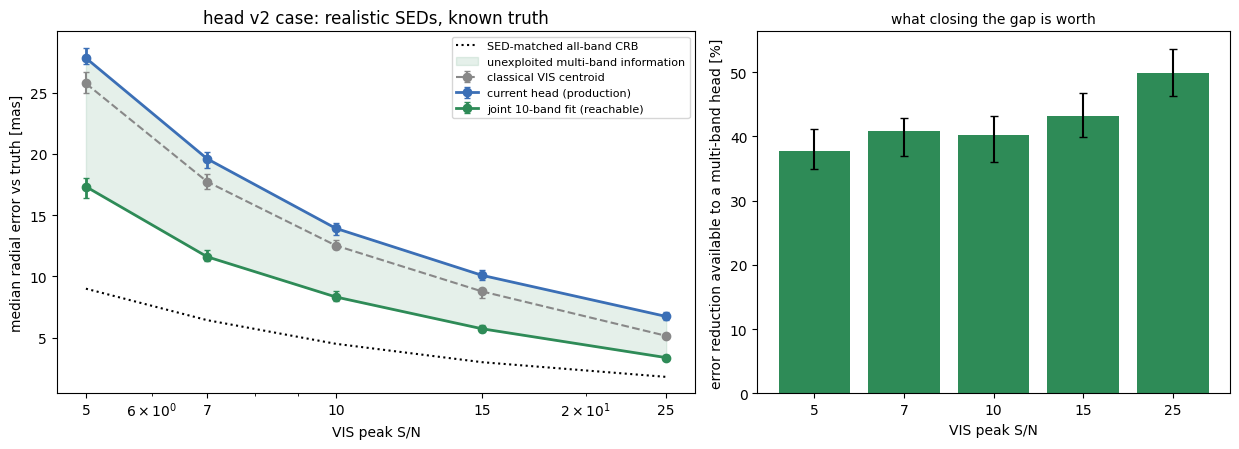

caveat: statistical budget only; on real sky the bright end is additionally floored by the shared systematics of nb25 par.5 / nb27.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={'width_ratios': [1.35, 1]})
ax = axes[0]
ax.errorbar(LV, curves['vis'], yerr=[np.array(curves['vis'])-np.array(lo['vis']), np.array(hi['vis'])-np.array(curves['vis'])], fmt='o--', color='#888888', label='classical VIS centroid', capsize=2)
ax.errorbar(LV, curves['head'], yerr=[np.array(curves['head'])-np.array(lo['head']), np.array(hi['head'])-np.array(curves['head'])], fmt='o-', color='#3b6fb6', lw=2, label='current head (production)', capsize=2)
ax.errorbar(LV, curves['joint'], yerr=[np.array(curves['joint'])-np.array(lo['joint']), np.array(hi['joint'])-np.array(curves['joint'])], fmt='o-', color='#2e8b57', lw=2, label='joint 10-band fit (reachable)', capsize=2)
ax.plot(LV, curves['crb'], ':', color='k', label='SED-matched all-band CRB')
ax.fill_between(LV, curves['joint'], curves['head'], color='#2e8b57', alpha=0.12,
                label='unexploited multi-band information')
ax.set(xscale='log', xlabel='VIS peak S/N', ylabel='median radial error vs truth [mas]',
       title='head v2 case: realistic SEDs, known truth')
ax.set_xticks(LV); ax.set_xticklabels([f'{s:.0f}' for s in LV])
ax.legend(fontsize=8)
axes[1].bar(range(len(LV)), imp_head, color='#2e8b57',
            yerr=[[m-c_[0] for m, c_ in zip(imp_head, imp_head_ci)],
                  [c_[1]-m for m, c_ in zip(imp_head, imp_head_ci)]], capsize=3)
axes[1].set_xticks(range(len(LV))); axes[1].set_xticklabels([f'{s:.0f}' for s in LV])
axes[1].set_xlabel('VIS peak S/N'); axes[1].set_ylabel('error reduction available to a multi-band head [%]')
axes[1].set_title('what closing the gap is worth', fontsize=10)
plt.tight_layout(); plt.savefig(OUT/'decision1_head_v2.png', dpi=150); plt.show()
print('caveat: statistical budget only; on real sky the bright end is additionally '
      'floored by the shared systematics of nb25 par.5 / nb27.')

## Decision plot 2 — the router-v2 case

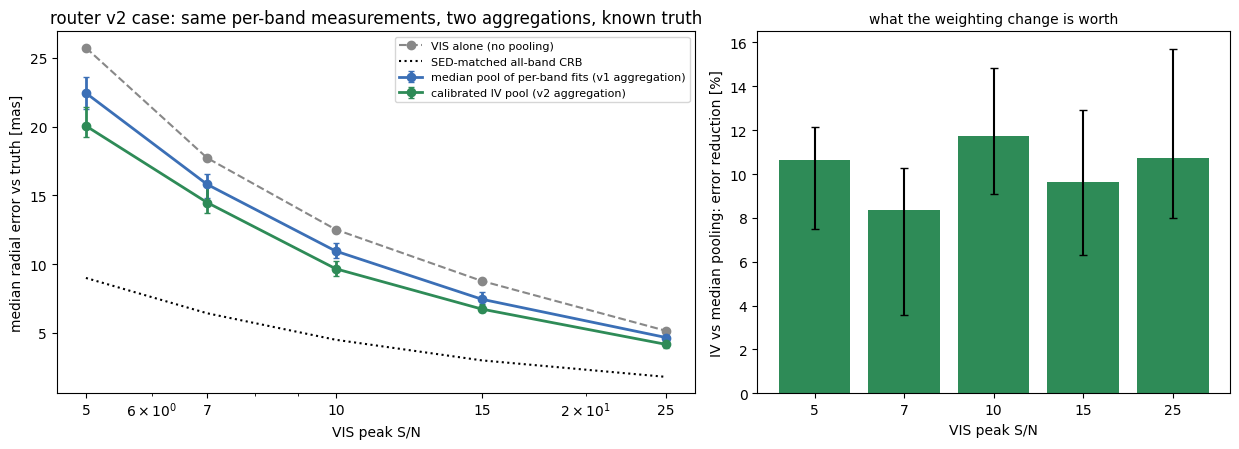

saved /home/shemmati/Work/Projects/JAISP/io/_nb28_outputs/v2_decision_curves.json


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={'width_ratios': [1.35, 1]})
ax = axes[0]
ax.errorbar(LV, curves['median_pool'], yerr=[np.array(curves['median_pool'])-np.array(lo['median_pool']), np.array(hi['median_pool'])-np.array(curves['median_pool'])], fmt='o-', color='#3b6fb6', lw=2, label='median pool of per-band fits (v1 aggregation)', capsize=2)
ax.errorbar(LV, curves['iv_pool'], yerr=[np.array(curves['iv_pool'])-np.array(lo['iv_pool']), np.array(hi['iv_pool'])-np.array(curves['iv_pool'])], fmt='o-', color='#2e8b57', lw=2, label='calibrated IV pool (v2 aggregation)', capsize=2)
ax.plot(LV, curves['vis'], 'o--', color='#888888', label='VIS alone (no pooling)')
ax.plot(LV, curves['crb'], ':', color='k', label='SED-matched all-band CRB')
ax.set(xscale='log', xlabel='VIS peak S/N', ylabel='median radial error vs truth [mas]',
       title='router v2 case: same per-band measurements, two aggregations, known truth')
ax.set_xticks(LV); ax.set_xticklabels([f'{s:.0f}' for s in LV])
ax.legend(fontsize=8)
axes[1].bar(range(len(LV)), imp_iv, color='#2e8b57',
            yerr=[[m-c_[0] for m, c_ in zip(imp_iv, imp_iv_ci)],
                  [c_[1]-m for m, c_ in zip(imp_iv, imp_iv_ci)]], capsize=3)
axes[1].set_xticks(range(len(LV))); axes[1].set_xticklabels([f'{s:.0f}' for s in LV])
axes[1].set_xlabel('VIS peak S/N'); axes[1].set_ylabel('IV vs median pooling: error reduction [%]')
axes[1].set_title('what the weighting change is worth', fontsize=10)
plt.tight_layout(); plt.savefig(OUT/'decision2_router_v2.png', dpi=150); plt.show()

json.dump({k: [float(v) for v in vv] for k, vv in curves.items()} | {'snr_levels': LV},
          open(OUT/'v2_decision_curves.json', 'w'), indent=1)
print('saved', OUT/'v2_decision_curves.json')

## Verdict (6 tiles × 20 sources × 7 test realizations = 840 samples/point; 68% cluster-bootstrap CIs, resampled by source)

**Router v2 (calibrated IV pooling): CONFIRMED — adopt.** IV beats the median pool at
every level, by a stable ~8–12%, and every confidence interval excludes zero
(worst case: +8.4% [+3.6, +10.3] at S/N 7; best measured: +11.8% [+9.1, +14.8] at
S/N 10). The IV pool also beats the *current production head* at every level
(9.7 ± 0.5 vs 13.9 ± 0.5 mas at S/N 10). The change is catalog-level arithmetic with
weights the router already computes; there is no identified regime where it loses.

**Head v2: the information gap is unambiguous — 38–50% at every level** (joint fit vs
current head: +40.2% [+36.0, +43.1] at S/N 10), far outside any statistical doubt. But
the same table shows classical multi-band machinery (IV pooling of per-band fits, 9.7 mas
at S/N 10) collects roughly half of that gap without any new network, and the classical
numbers here are flattered by a matched PSF model (the fit uses the exact injected
Gaussian; real sky requires per-band ePSFs, where a learned head has the advantage of
learning the PSF implicitly). The honest case for head v2 is therefore: reach joint-fit
performance *amortized* (no per-source optimizer, no explicit per-band PSF model) and
hold it where classical assumptions break (blends, real morphology, PSF mismatch) — and
its benchmark must be the classical multi-band alternatives, not the current head.

Secondary observations, now solid: the current head trails even the single-band VIS
matched fit under realistic conditions (13.9 vs 12.5 mas at S/N 10) — its contribution
was always the *transfer* of VIS localization to the other bands, not VIS-frame
precision; and at S/N 5 even the joint fit misses the CRB by ~2× (17.3 vs 9.0 mas) —
maximum-likelihood fitting is asymptotic, so CRBs must not be quoted as faint-end targets
(nb25, Rule 1).

**Recommendations.** (1) Adopt router-v2 IV pooling now; expected ~10% catalog-wide
improvement at fixed inputs, on top of the pooling itself beating the current
single-position output. (2) Head v2 proceeds only under the amortized-joint-fit +
robustness pitch, benchmarked against classical IV pooling and an ePSF joint fit.
(3) All numbers are the statistical budget (WCS = truth); the real-sky bright end remains
floored by the shared systematics of nb25 §5 / nb27.

**Caveats.** Gaussian PSFs, isolated sources; the head evaluated at production-like
queries but with matched χ² fits (not `refine_centroids_psf_fit`) as the classical
baseline; single field (patch-25 tiles of ECDFS).